In [3]:
import numpy as np
import tensorflow as tf

from matplotlib import pyplot as plt
from sklearn.model_selection import KFold
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Importando dados

Conforme especificado na descrição da atividade, importaremos os dados do dataset CIFAR-10  (https://www.tensorflow.org/datasets/catalog/cifar10), também disponível no TensorFlow.

As imagens agora tem a forma 32 x 32 x 3.

O dataset consiste de 60000 32x32 imagens coloridas de 10 classes, com 6000 imagens por classe. Há 50000 imagens de treinamento e 10000 imagens de teste.

Entendendo a classificação do dataset. Cada classe tem um número associado de 0 a 9 com a sua classificação, nosso objetivo é criar um modelo capaz de entender qual tipo de imagens estamos lidando.




In [4]:
# carregando dataset
(trainX, trainY), (testX, testY) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


Faremos algumas adequações para que os dados sejam usados no modelo de CNN. Basicamente, colocamos os valores dos pixels em uma escala de 0 a 1, visto que os valores originais dos pixels das imagens correspondem a uma escala de 0 a 255. Também transformamos nossa variável alvo em uma codificação one-hos. No CIFAR-10 teremos algumas alterações, a primeira delas é que não precisaremos da opção cmap "gray", outra coisa é que não iremos necessitar do reshape, já que o dataset já possui 3 canais, RGB.

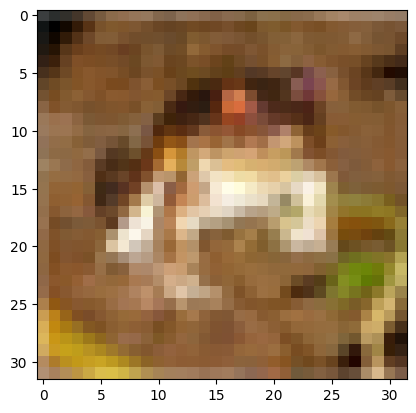

In [11]:
plt.imshow(trainX[0]);

In [5]:
# Convertendo valores dos pixels em float
trainX = trainX.astype('float32')
testX = testX.astype('float32')

# normalização para escala [0-1]
trainX = trainX / 255.0
testX = testX / 255.0

# transformando a variável alvo (target) para uma codificação one hot
trainY = to_categorical(trainY)
testY = to_categorical(testY)

# Construindo o modelo

O modelo usado será bem simples:
* Uma única camada convolucional com 32 filtros de tamanho 3 x 3 e função de ativação ReLU
* Camada MaxPooling para redução de dimensionalidade
* Transformação do resultado em um vetor
* Camada totalmente conectada com 100 neurônios e função de ativação ReLU
* Camada de saída softmax para estimar a probabilidade da entrada da rede pertencer a cada uma das 10 classes (dígitos 0 a 9)


Para treinamento do modelo, usaremos o algoritmo de otimização clássico do gradiente descendente estocástico (SDG), com a função objetiva como a entropia cruzada categórica. Nossa principal métrica de desempenho será a acurácia

In [13]:
# definindo modelo
def define_model():
  model = Sequential()
  model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2)))
  model.add(Flatten())
  model.add(Dense(100, activation='relu'))
  model.add(Dense(10, activation='softmax'))

  # compilando modelo
  opt = Adam(learning_rate=0.001)
  model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
  return model

# Treinamento do modelo

O treinamento será realizado usando o método da validação cruzada k-partições (k-fold) com k=5. Tal validação cruzada faz a divisão dos dados em 5 grupos de tamanho igual, sendo realizadas 5 treinamentos distintos. A cada treinamento, 4 grupos de dados são utilizados para treinar o modelo e o grupo remanescente é usado para teste do desempenho do modelo treinado.



* O principal intuito da validação k-fold é acessar a incerteza do desempenho do modelo

In [14]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4469 - loss: 1.5980 - val_accuracy: 0.5746 - val_loss: 1.2089
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6417 - loss: 1.0231 - val_accuracy: 0.5208 - val_loss: 1.4387
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7208 - loss: 0.8031 - val_accuracy: 0.6092 - val_loss: 1.1339
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7815 - loss: 0.6241 - val_accuracy: 0.6096 - val_loss: 1.2566
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8381 - loss: 0.4665 - val_accuracy: 0.6188 - val_loss: 1.3439
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8869 - loss: 0.3296 - val_accuracy: 0.5944 - val_loss: 1.6657
> 60.920
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4525 - loss: 1.5849 - val_accuracy: 0.5703 - val_loss: 1.2316
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6584 - loss: 

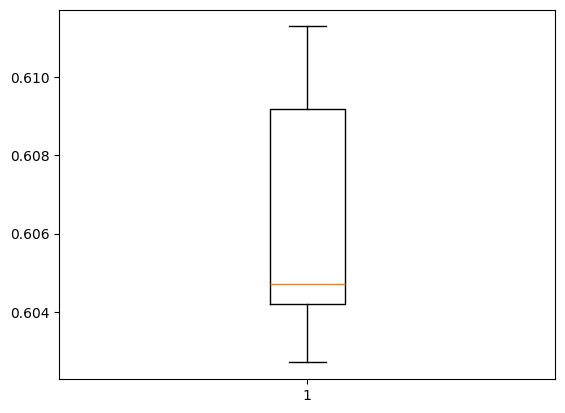

In [15]:
scores = []
histories = []

# definindo a validação k-fold
kfold = KFold(5, shuffle=True, random_state=1)

# loop para as k-folds (cada fold usa subconjuntos de treino e teste diferentes)
for train_ix, test_ix in kfold.split(trainX):

  model = define_model()

  # recorta dados de acordo com índices da k-fold
  train_data, train_target, val_data, val_target = trainX[train_ix], trainY[train_ix], trainX[test_ix], trainY[test_ix]

  # treinamento do modelo
  history = model.fit(train_data, train_target,
                      epochs=10, batch_size=32,
                      validation_data=(val_data, val_target),
                      verbose=1, callbacks=[callback])

  # desempenho do modelo
  _, acc = model.evaluate(val_data, val_target, verbose=0)
  print('> %.3f' % (acc * 100.0))

  # armazena resultados de cada modelo treinado dentro da k-fold
  scores.append(acc)
  histories.append(history)

print('Acurácia: média=%.3f desvio=%.3f' % (np.mean(scores)*100, np.std(scores)*100))
plt.boxplot(scores)
plt.show()

In [19]:
labels_cifar10 = [
    'airplane',  # 0
    'automobile',# 1
    'bird',      # 2
    'cat',       # 3
    'deer',      # 4
    'dog',       # 5
    'frog',      # 6
    'horse',     # 7
    'ship',      # 8
    'truck'      # 9
]

# Testando modelo no conjunto de teste

Agora avaliaremos o desempenho do modelo em dados do conjunto de teste separado nas etapas iniciais deste exercício
* Abaixo temos a primeira imagem do conjunto de teste

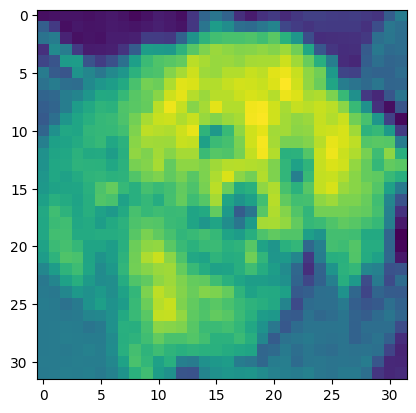

In [29]:
plt.imshow(testX[1000,:,:,0]);

Usaremos o último modelo treinado na validação cruzada k-fold para classificar qual número temos na imagem (podemos também salvar cada um dos modelos intermediários e usar o que apresentar maior performance ou fazer um comitê de votação com os 5 modelos disponíveis)

* temos que fazer uma expansão de dimensão para que nossa imagem tenha um formato 1 x 28 x 28 x 1. Isso é necessário pois treinamos nosso modelo usando mini conjuntos de imagens (como nosso batch size era de 32, o formato passado para o modelo a cada passo de treinamento era 32 x 28 x 28 x 1)

In [30]:
pred_idx = np.argmax(model.predict(np.expand_dims(testX[1000], axis=0)))
pred_label = labels_cifar10[pred_idx]
print(pred_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
dog


In [31]:
np.argmax(model.predict(np.expand_dims(testX[1000], axis=0)))
pred_label = labels_cifar10[pred_idx]
print(pred_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
dog


# Comaparação com o MNIST


*   Houve muita diferença no desempenho da rede treinada quando comparado ao exemplo?


O exemplo obteve esses resultados no treinamento:


Acurácia: média=97.960 desvio=0.327
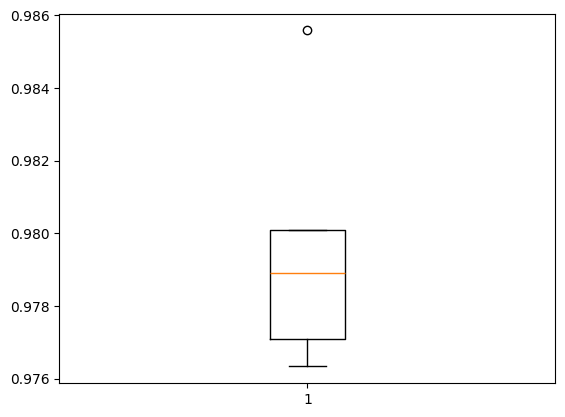

Se compararmos o desempenho do CIFAT-10 com o MNIST veremos que o MNIST se sobressai bastante, o dataset tem um problema mais simples, números escritos a mão tem menos variação de cor, textura e fundo. O CIFAR-10 contém objetos reais com variação de iluminação, perspectiva, cores e ruído, o que torna a classificação muito mais desafiadora.

Se olharmos para o desvio ambos tem o desvio baixo, o que significa que o desempenho é consistente entre as diferentes partições do k-fold. Isso sugere que a variação não vem da divisão dos dados, mas sim da dificuldade intrínseca do problema.

# Experimento 1: Experimente adicionar mais dois blocos de camadas Conv2D (64 filtros 3x3 - relu) + MaxPooling (2 x 2) antes da camada Flatten

Teremos que alterar o modelo, então o refaremos aqui:

In [6]:
# definindo modelo
def define_model():
  model = Sequential()
  model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2)))
  #novo bloco(1)
  model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2)))
  #novo bloco(2)
  model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2)))

  model.add(Flatten())
  model.add(Dense(100, activation='relu'))
  model.add(Dense(10, activation='softmax'))

  # compilando modelo
  opt = Adam(learning_rate=0.001)
  model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
  return model

In [7]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.4357 - loss: 1.6170 - val_accuracy: 0.5088 - val_loss: 1.4645
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6474 - loss: 1.0017 - val_accuracy: 0.6617 - val_loss: 0.9567
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7137 - loss: 0.8065 - val_accuracy: 0.6270 - val_loss: 1.0921
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7654 - loss: 0.6706 - val_accuracy: 0.7006 - val_loss: 0.8705
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7973 - loss: 0.5808 - val_accuracy: 0.6791 - val_loss: 0.9667
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8222 - loss: 0.5107 - val_accuracy: 0.6587 - val_loss: 1.1008
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8474 - loss: 0.4321 - val_accuracy: 0.7124 - val_loss: 0.9085
> 70.060
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.4409 - lo

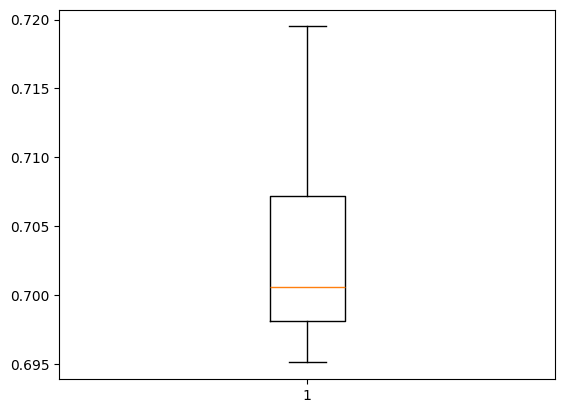

In [8]:
scores = []
histories = []

# definindo a validação k-fold
kfold = KFold(5, shuffle=True, random_state=1)

# loop para as k-folds (cada fold usa subconjuntos de treino e teste diferentes)
for train_ix, test_ix in kfold.split(trainX):

  model = define_model()

  # recorta dados de acordo com índices da k-fold
  train_data, train_target, val_data, val_target = trainX[train_ix], trainY[train_ix], trainX[test_ix], trainY[test_ix]

  # treinamento do modelo
  history = model.fit(train_data, train_target,
                      epochs=10, batch_size=32,
                      validation_data=(val_data, val_target),
                      verbose=1, callbacks=[callback])

  # desempenho do modelo
  _, acc = model.evaluate(val_data, val_target, verbose=0)
  print('> %.3f' % (acc * 100.0))

  # armazena resultados de cada modelo treinado dentro da k-fold
  scores.append(acc)
  histories.append(history)

print('Acurácia: média=%.3f desvio=%.3f' % (np.mean(scores)*100, np.std(scores)*100))
plt.boxplot(scores)
plt.show()

O salto de ~60,6% → ~70,4% representa um aumento de quase 10 pontos percentuais na acurácia média. Isso mostra que aumentar a profundidade e a quantidade de filtros ajudou o modelo a capturar melhor as variações visuais do CIFAR‑10.

O desvio, entretanto, aumentou de 0,33% → 0,87%, indicando que o desempenho variou um pouco mais entre as folds. Isso pode ser efeito da maior complexidade do modelo, que é mais sensível a variações nos dados de treino/validação.

# Experimento 2: Seguindo o modelo modificado no item anterior, experimente adicionar um Dropout de 20% após cada camada MaxPooling

Teremos que alterar o modelo, então o refaremos aqui:

In [10]:
# definindo modelo
def define_model():
  model = Sequential()
  model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2)))
  model.add(Dropout(0.2))  # Dropout 20%
  #novo bloco(1)
  model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2)))
  model.add(Dropout(0.2))  # Dropout 20%
  #novo bloco(2)
  model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2)))
  model.add(Dropout(0.2))  # Dropout 20%

  model.add(Flatten())
  model.add(Dense(100, activation='relu'))
  model.add(Dense(10, activation='softmax'))

  # compilando modelo
  opt = Adam(learning_rate=0.001)
  model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
  return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.3662 - loss: 1.7932 - val_accuracy: 0.4919 - val_loss: 1.4401
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.5675 - loss: 1.2255 - val_accuracy: 0.5920 - val_loss: 1.1372
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6269 - loss: 1.0462 - val_accuracy: 0.6505 - val_loss: 1.0041
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6725 - loss: 0.9289 - val_accuracy: 0.6670 - val_loss: 0.9589
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6994 - loss: 0.8503 - val_accuracy: 0.6994 - val_loss: 0.8629
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7182 - loss: 0.7911 - val_accuracy: 0.7067 - val_loss: 0.8411
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7311 - loss: 0.7591 - val_accuracy: 0.6219 - val_loss: 1.1225
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7450 - loss: 0.71

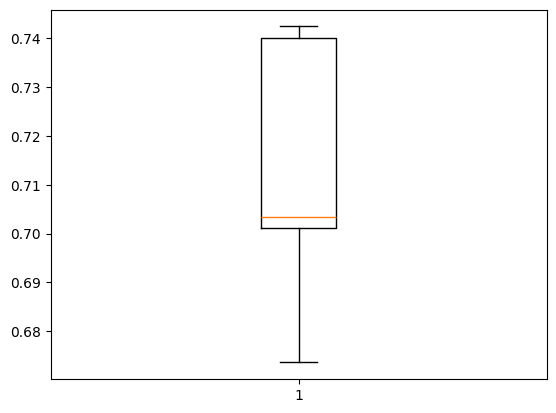

In [11]:
scores = []
histories = []

# definindo a validação k-fold
kfold = KFold(5, shuffle=True, random_state=1)

# loop para as k-folds (cada fold usa subconjuntos de treino e teste diferentes)
for train_ix, test_ix in kfold.split(trainX):

  model = define_model()

  # recorta dados de acordo com índices da k-fold
  train_data, train_target, val_data, val_target = trainX[train_ix], trainY[train_ix], trainX[test_ix], trainY[test_ix]

  # treinamento do modelo
  history = model.fit(train_data, train_target,
                      epochs=10, batch_size=32,
                      validation_data=(val_data, val_target),
                      verbose=1, callbacks=[callback])

  # desempenho do modelo
  _, acc = model.evaluate(val_data, val_target, verbose=0)
  print('> %.3f' % (acc * 100.0))

  # armazena resultados de cada modelo treinado dentro da k-fold
  scores.append(acc)
  histories.append(history)

print('Acurácia: média=%.3f desvio=%.3f' % (np.mean(scores)*100, np.std(scores)*100))
plt.boxplot(scores)
plt.show()

A acurácia média subiu levemente, mas o desvio padrão aumentou bastante (0,867 → 2,598), mostrando que o efeito do Dropout foi mais inconsistente entre as folds. Isso é esperado: Dropout adiciona aleatoriedade ao treino, o que pode beneficiar ou prejudicar dependendo da partição dos dados.

Para estabilizar e possivelmente aumentar ainda mais a acurácia, vale testar Data Augmentation (rotação, flips, shifts, zoom) e talvez mais épocas com Early Stopping.